# 🚀 GoViralIQ
## Notebook 1: Data Exploration
**Project:** Predicting Instagram Engagement & Auditing Algorithmic Fairness Across Creator Niches  
**Author:** Chastity Lewis  
**Course:** CISC 540 — Computational Data Analysis | Mercy University | Spring 2026  
**Dataset:** Viral Social Media Trends & Engagement Analysis (Kaggle)

---

### 📌 Notebook Goals
In this notebook we will:
1. Load and inspect the dataset
2. Understand the shape, columns, and data types
3. Check for missing values and duplicates
4. Explore basic statistics
5. Engineer our key target variable: `engagement_rate`
6. Ask initial research questions based on what we find

---

## Step 1: Install & Import Libraries

In [1]:
# Install any missing libraries (run this first in Colab)
!pip install pandas numpy matplotlib seaborn --quiet

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#6B21A8', '#D8B4FE', '#1F1F1F', '#F3E8FF', '#9333EA']

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Step 2: Load the Dataset

> **How to upload your file in Google Colab:**  
> Run the cell below, click "Choose Files", and select your downloaded CSV from Kaggle.

In [7]:
# Option A — Upload manually in Google Colab
from google.colab import files
uploaded = files.upload()

Saving Viral_Social_Media_Trends.csv to Viral_Social_Media_Trends.csv
Saving Cleaned_Viral_Social_Media_Trends.csv to Cleaned_Viral_Social_Media_Trends.csv


In [8]:
# Option B — Load directly if you know the filename
# Replace 'your_file.csv' with the actual filename from Kaggle
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ Dataset loaded: {filename}')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Dataset loaded: Viral_Social_Media_Trends.csv
📊 Shape: 5,000 rows × 10 columns


## Step 3: First Look at the Data

In [9]:
# Preview the first 5 rows
print('🔍 First 5 rows:')
df.head()

🔍 First 5 rows:


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


In [10]:
# Preview the last 5 rows
print('🔍 Last 5 rows:')
df.tail()

🔍 Last 5 rows:


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
4995,Post_4996,YouTube,#Education,Video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,Instagram,#Education,Video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,YouTube,#Fashion,Shorts,USA,2004080,32401,75229,33875,Low
4998,Post_4999,Instagram,#Gaming,Shorts,Canada,2221665,46996,12954,42832,Low
4999,Post_5000,Instagram,#Fashion,Reel,Japan,2224007,72744,29945,46381,Low


In [11]:
# Column names and data types
print('📋 Column Names and Data Types:')
print(df.dtypes)
print(f'\nTotal columns: {len(df.columns)}')

📋 Column Names and Data Types:
Post_ID             object
Platform            object
Hashtag             object
Content_Type        object
Region              object
Views                int64
Likes                int64
Shares               int64
Comments             int64
Engagement_Level    object
dtype: object

Total columns: 10


In [12]:
# Basic statistics for all numeric columns
print('📈 Descriptive Statistics:')
df.describe()

📈 Descriptive Statistics:


,Views,Likes,Shares,Comments
count,5000.00,5000.00,5000.00,5000.00
mean,2494066.44,251475.03,50519.56,24888.39
std,1459489.82,144349.58,29066.36,14284.50
min,1266.00,490.00,52.00,18.00
25%,1186207.25,126892.25,25029.00,12305.25
50%,2497373.00,249443.00,50839.50,25004.00
75%,3759781.00,373970.75,75774.25,37072.75
max,4999430.00,499922.00,99978.00,49993.00


## Step 4: Check Data Quality

In [16]:
# Check for missing values
print('❓ Missing Values Per Column:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found!')
else:
    print(missing_df)

❓ Missing Values Per Column:
✅ No missing values found!


In [17]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'🔁 Duplicate Rows: {duplicates:,}')

if duplicates > 0:
    print(f'⚠️  {duplicates} duplicates found — will remove in Notebook 2 (Data Cleaning)')
else:
    print('✅ No duplicate rows found!')

🔁 Duplicate Rows: 0
✅ No duplicate rows found!


In [18]:
# Check unique values in categorical columns
print('🏷️  Unique Values in Categorical Columns:')
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')
    if df[col].nunique() <= 20:
        print(f'    Values: {df[col].unique().tolist()}')

🏷️  Unique Values in Categorical Columns:
  Post_ID: 5000 unique values
  Platform: 4 unique values
    Values: ['TikTok', 'Instagram', 'Twitter', 'YouTube']
  Hashtag: 10 unique values
    Values: ['#Challenge', '#Education', '#Dance', '#Comedy', '#Gaming', '#Music', '#Viral', '#Fitness', '#Tech', '#Fashion']
  Content_Type: 6 unique values
    Values: ['Video', 'Shorts', 'Post', 'Tweet', 'Live Stream', 'Reel']
  Region: 8 unique values
    Values: ['UK', 'India', 'Brazil', 'Australia', 'Japan', 'Germany', 'Canada', 'USA']
  Engagement_Level: 3 unique values
    Values: ['High', 'Medium', 'Low']


## Step 5: Filter for Instagram Data

> Since this dataset covers multiple platforms (TikTok, Instagram, Twitter, YouTube), we filter for Instagram only.

In [19]:
# Check what platform column is called
# Common names: 'Platform', 'platform', 'social_media', 'source'
platform_col = None
for col in df.columns:
    if 'platform' in col.lower() or 'source' in col.lower():
        platform_col = col
        break

if platform_col:
    print(f'✅ Platform column found: "{platform_col}"')
    print(f'\nPlatform distribution:')
    print(df[platform_col].value_counts())
else:
    print('⚠️  No platform column found — dataset may already be Instagram-only')
    print('Columns available:', df.columns.tolist())

✅ Platform column found: "Platform"

Platform distribution:
Platform
YouTube      1324
TikTok       1260
Instagram    1212
Twitter      1204
Name: count, dtype: int64


In [20]:
# Filter for Instagram only (run this if platform column exists)
if platform_col:
    # Try common variations of the Instagram label
    instagram_labels = ['Instagram', 'instagram', 'INSTAGRAM', 'IG']
    df_ig = df[df[platform_col].isin(instagram_labels)].copy()
    print(f'✅ Instagram rows: {len(df_ig):,} (filtered from {len(df):,} total)')
else:
    df_ig = df.copy()
    print(f'✅ Using full dataset: {len(df_ig):,} rows')

✅ Instagram rows: 1,212 (filtered from 5,000 total)


## Step 6: Engineer the Engagement Rate

> **Engagement Rate** is our key metric and target variable.  
> Formula: `engagement_rate = (likes + comments) / followers * 100`  
> This normalizes engagement so we can compare creators fairly regardless of follower count.

In [30]:
LIKES_COL     = 'Likes'
COMMENTS_COL  = 'Comments'
VIEWS_COL     = 'Views'
CATEGORY_COL  = 'Content_Type'

# Engineer engagement rate
df_ig['engagement_rate'] = (
    (df_ig[LIKES_COL] + df_ig[COMMENTS_COL] + df_ig['Shares']) / df_ig[VIEWS_COL] * 100
).round(4)

# Create binary viral target variable
threshold = df_ig['engagement_rate'].quantile(0.80)
df_ig['viral'] = (df_ig['engagement_rate'] >= threshold).astype(int)

print(f'✅ engagement_rate engineered successfully!')
print(f'✅ Viral threshold (80th percentile): {threshold:.2f}%')
print(f'\nViral post distribution:')
print(df_ig['viral'].value_counts())
print(f'\nViral rate: {df_ig["viral"].mean()*100:.1f}% of posts')

✅ engagement_rate engineered successfully!
✅ Viral threshold (80th percentile): 39.73%

Viral post distribution:
viral
0    969
1    243
Name: count, dtype: int64

Viral rate: 20.0% of posts


## Step 7: Initial Visualizations

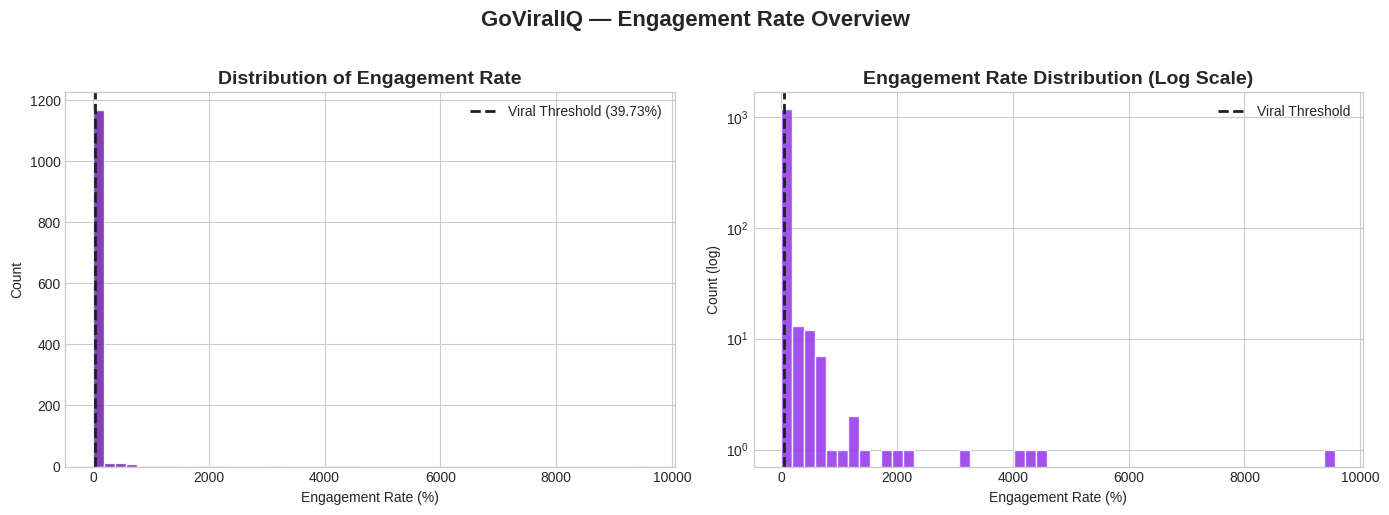

✅ Chart saved as engagement_distribution.png


In [31]:
# Distribution of engagement rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df_ig['engagement_rate'], bins=50, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Engagement Rate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Engagement Rate (%)')
axes[0].set_ylabel('Count')
axes[0].axvline(threshold, color=COLORS[2], linestyle='--', linewidth=2, label=f'Viral Threshold ({threshold:.2f}%)')
axes[0].legend()

# Log scale for better visibility
axes[1].hist(df_ig['engagement_rate'], bins=50, color=COLORS[4], edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title('Engagement Rate Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Engagement Rate (%)')
axes[1].set_ylabel('Count (log)')
axes[1].axvline(threshold, color=COLORS[2], linestyle='--', linewidth=2, label=f'Viral Threshold')
axes[1].legend()

plt.suptitle('GoViralIQ — Engagement Rate Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('engagement_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as engagement_distribution.png')

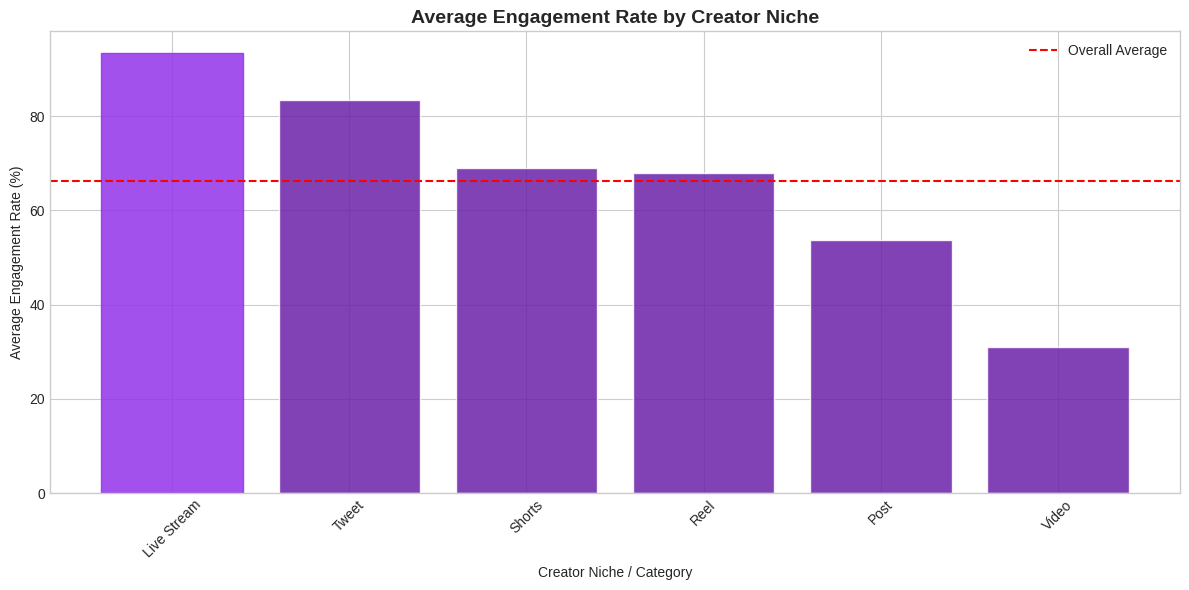

✅ Chart saved as engagement_by_niche.png


In [32]:
# Engagement rate by category/niche (the fairness foundation)
if CATEGORY_COL in df_ig.columns:
    top_categories = df_ig[CATEGORY_COL].value_counts().head(10).index
    df_cat = df_ig[df_ig[CATEGORY_COL].isin(top_categories)]

    fig, ax = plt.subplots(figsize=(12, 6))
    category_means = df_cat.groupby(CATEGORY_COL)['engagement_rate'].mean().sort_values(ascending=False)
    bars = ax.bar(category_means.index, category_means.values, color=COLORS[0], edgecolor='white', alpha=0.85)

    # Color the top bar differently
    bars[0].set_color(COLORS[4])

    ax.set_title('Average Engagement Rate by Creator Niche', fontsize=14, fontweight='bold')
    ax.set_xlabel('Creator Niche / Category')
    ax.set_ylabel('Average Engagement Rate (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(df_ig['engagement_rate'].mean(), color='red', linestyle='--', linewidth=1.5, label='Overall Average')
    ax.legend()

    plt.tight_layout()
    plt.savefig('engagement_by_niche.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Chart saved as engagement_by_niche.png')
else:
    print(f'⚠️  Category column "{CATEGORY_COL}" not found. Update CATEGORY_COL above.')

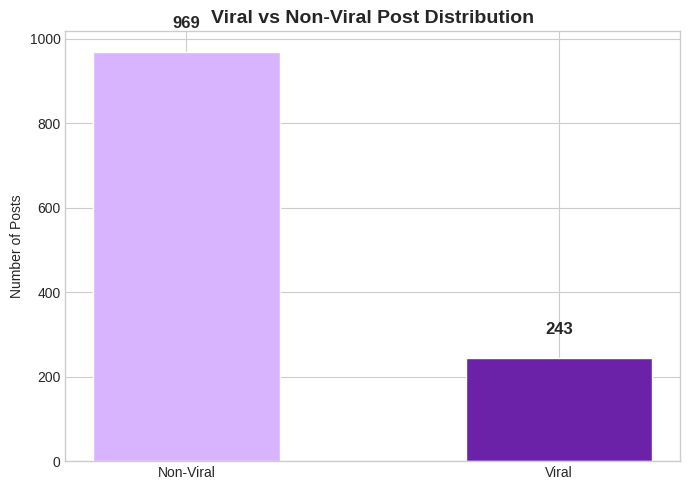

✅ Chart saved as viral_distribution.png


In [33]:
# Viral vs Non-Viral post counts
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Non-Viral', 'Viral']
counts = df_ig['viral'].value_counts().sort_index()
bars = ax.bar(labels, counts.values, color=[COLORS[1], COLORS[0]], edgecolor='white', width=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Viral vs Non-Viral Post Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Posts')
plt.tight_layout()
plt.savefig('viral_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as viral_distribution.png')

## Step 8: Summary & Key Findings

In [34]:
print('=' * 55)
print('         GoViralIQ — Notebook 1 Summary')
print('=' * 55)
print(f'\n📊 Dataset Shape:         {df_ig.shape[0]:,} rows × {df_ig.shape[1]} columns')
print(f'❓ Missing Values:         {df_ig.isnull().sum().sum():,} total')
print(f'🔁 Duplicate Rows:         {df_ig.duplicated().sum():,}')
print(f'\n📈 Engagement Rate Stats:')
print(f'   Mean:    {df_ig["engagement_rate"].mean():.2f}%')
print(f'   Median:  {df_ig["engagement_rate"].median():.2f}%')
print(f'   Max:     {df_ig["engagement_rate"].max():.2f}%')
print(f'   Min:     {df_ig["engagement_rate"].min():.2f}%')
print(f'\n🚀 Viral Threshold:        {threshold:.2f}% (80th percentile)')
print(f'   Viral Posts:           {df_ig["viral"].sum():,} ({df_ig["viral"].mean()*100:.1f}%)')
print(f'   Non-Viral Posts:       {(df_ig["viral"]==0).sum():,} ({(df_ig["viral"]==0).mean()*100:.1f}%)')
print('\n' + '=' * 55)
print('\n✅ Next: Notebook 02 — Data Cleaning & Feature Engineering')

         GoViralIQ — Notebook 1 Summary

📊 Dataset Shape:         1,212 rows × 12 columns
❓ Missing Values:         0 total
🔁 Duplicate Rows:         0

📈 Engagement Rate Stats:
   Mean:    66.21%
   Median:  13.80%
   Max:     9569.16%
   Min:     0.42%

🚀 Viral Threshold:        39.73% (80th percentile)
   Viral Posts:           243 (20.0%)
   Non-Viral Posts:       969 (80.0%)


✅ Next: Notebook 02 — Data Cleaning & Feature Engineering


## Step 9: Save Cleaned Exploration Output

In [35]:
# Save the Instagram-filtered dataset for use in Notebook 2
df_ig.to_csv('goviraliq_instagram_raw.csv', index=False)
print(f'✅ Dataset saved as goviraliq_instagram_raw.csv')
print(f'   Shape: {df_ig.shape[0]:,} rows × {df_ig.shape[1]} columns')
print(f'\n📁 Files created this notebook:')
print('   - goviraliq_instagram_raw.csv')
print('   - engagement_distribution.png')
print('   - engagement_by_niche.png')
print('   - viral_distribution.png')

✅ Dataset saved as goviraliq_instagram_raw.csv
   Shape: 1,212 rows × 12 columns

📁 Files created this notebook:
   - goviraliq_instagram_raw.csv
   - engagement_distribution.png
   - engagement_by_niche.png
   - viral_distribution.png
